# TẦNG 4: HỆ THỐNG KIỂM TRA CHỮ KÝ & CON DẤU MỘC ĐỎ (KIDO LOGISTICS AUDIT)
### Pipeline Tự Động Hóa Đối Soát Chứng Từ Giao Nhận - Chuẩn Nghiệp Vụ Kế Toán KIDO (Stage 4 Release: v1.1.1 | Detector Core: v1.1.0)

---

## 1. Bức tranh toàn cảnh & Mục tiêu Tầng 4
Sau khi hoàn thành:
- **Tầng 1 (`ocr-tang1-ver2.ipynb`)**: Chuẩn hóa góc xoay, nắn thẳng phối cảnh A4 và bảo toàn tuyệt đối không gian 3 kênh màu RGB/BGR.
- **Tầng 2 (`ocr-tang2-classify.ipynb`)**: Phân loại chính xác 97.22% (0% False Positive) 13 loại biểu mẫu và bóc tách `shipment_id`, `po_no`, `invoice_no`.
- **Tầng 3 (`ocr-tang3-batch.ipynb`)**: Ghép nối đa trang (`multi-page stitching`), gom 65 chứng từ vào 22 Lô chuyến xe, đối soát checklist 68 quy tắc KIDO và trích xuất Bounding Box chữ ký chuẩn hóa (`signature_targets`).

**Mục tiêu của Tầng 4 (Stage 4 Release: v1.1.1 | Detector Core: v1.1.0):**
Xây dựng **Hệ Thống Kiểm Định Song Song Đa Tầng (Hybrid Multi-Layer Verification Core)** kiểm tra evidence hình ảnh thực tế tại các vùng mục tiêu do Tầng 3 cung cấp:
1. **Con dấu mộc đỏ pháp nhân công ty** (trên Hóa đơn, Phiếu xuất kho kiêm vận chuyển nội bộ).
2. **Con dấu mộc vuông / mộc tròn tiếp nhận của siêu thị** (Co.opmart, WinMart, Lotte, Big C, Bách Hóa Xanh...).
3. **Chữ ký mực sống của các bên liên quan** (Thủ kho, Lái xe, Khách hàng, Người lập phiếu).
4. **Cơ chế tách lớp màu dựa trên HSV (HSV-based Color-Layer Separation)** khi con dấu đỏ đóng trùm lên chữ ký mực xanh.
5. **Cơ chế dự phòng hình thái học (Morphological & Connected-Components Fallback)** cho các chứng từ là bản photocopy đen trắng.

**Quy chuẩn Hardening & Chống False Acceptance (Stage 4 Release: v1.1.1 | Detector Core: v1.1.0):**
- **Input Quality Gate & Fail-Safe:** Phát hiện ảnh thiếu (`IMAGE_NOT_FOUND`), buffer ảnh hỏng (`MISSING_OR_CORRUPT_IMAGE`), hình học bbox đảo ngược (`INVALID_OR_EMPTY_BBOX`), crop sub-10px (`ROI_TOO_SMALL`), cảnh báo mờ/tương phản cực thấp.
- **Contract Correctness:** Xử lý rành mạch `required` vs `optional` targets. Verdict văn bản chỉ dựa trên required targets; optional targets vẫn được audit đầy đủ.
- **Bảo vệ Trạng Thái:** Phân biệt tuyệt đối giữa `KHONG_YEU_CAU` (theo quy chuẩn nghiệp vụ) và `UNMAPPED` (chứng từ thiếu mapping). Không bao giờ chuyển `UNMAPPED` thành `KHONG_YEU_CAU`.
- **Bảo vệ Trang Quét:** Chặn đứng 100% silent clamping/fallback khi `target.page` vượt quá số trang thực tế ($	o$ `INVALID_PAGE_MAPPING`, `detected = False`).
- **Target-level Modality:** Xác định tài liệu màu (`TRUE_COLOR`) hay đen trắng (`PHOTOCOPY_BW`) ở cấp từng trang mục tiêu riêng biệt.
- **Engine A Chống Lẫn Màu:** Loại bỏ triệt để việc chấp nhận mực xanh trong ô dấu đỏ.
- **Benchmark Độc Lập v2:** Đối chiếu với Ground Truth độc lập cấp target `output/stage4_gt_independent_v2.json` (thẩm định trực quan ảnh gốc trên 185 targets) đo lường khách quan Precision, Recall, F1, Accuracy.
- **Quy chuẩn Kiểm định:** Detector Core: v1.1.0 | Stage 4 Release: v1.1.1 | Benchmark purpose: evaluation only | Threshold tuning on benchmark: NO | Stage3: FROZEN WITH KNOWN LIMITATION | Regression: 25/25 PASS.
- **Lưu ý Bản chất Nghiệp vụ & Pháp lý:** Hệ thống phát hiện bằng chứng hình ảnh (evidence verification detector) hỗ trợ kế toán đối soát, tự động gán `confidence_type = HEURISTIC_SCORE`, không phải hệ thống giám định pháp lý chữ ký tay.

In [1]:
# CELL 2: Import Thư viện & Thiết lập Môi trường
import os
import sys
import json
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Thiết lập bảng mã UTF-8 an toàn trên mọi môi trường
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

# Cấu hình Matplotlib hiển thị sắc nét (Tuân thủ chuẩn IPython 9+ không dùng directive inline)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI']
plt.rcParams['axes.unicode_minus'] = False

print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print("Môi trường xử lý Tầng 4 (Stage 4 Release: v1.1.1 | Detector Core: v1.1.0) đã sẵn sàng!")

OpenCV Version: 4.14.0
NumPy Version: 2.4.6
Pandas Version: 3.0.5
Môi trường xử lý Tầng 4 (Stage 4 Release: v1.1.1 | Detector Core: v1.1.0) đã sẵn sàng!


In [2]:
# CELL 3: Nạp Manifest Tầng 3 & Thiết lập Hằng số Cấu hình Kiểm Định
MANIFEST_PATH = "output/stage3_out/stage3_batched_manifest.json"
SAMPLES_DIR = "output/form_samples"
STAGE4_OUT_DIR = "output/stage4_out"
os.makedirs(STAGE4_OUT_DIR, exist_ok=True)

with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest_data = json.load(f)

total_docs_count = sum(len(b.get('documents', [])) for b in manifest_data['batches'])
total_dossiers_count = sum(len(b.get('order_dossiers', [])) for b in manifest_data['batches'])
print(f"Đã nạp thành công Manifest Tầng 3:")
print(f" - Tổng số Lô chuyến xe (Batches): {len(manifest_data['batches'])}")
print(f" - Tổng số Tài liệu hoàn chỉnh: {total_docs_count}")
print(f" - Tổng số Hồ sơ đơn hàng (Order Dossiers): {total_dossiers_count}")

# Cấu hình dải màu HSV chuẩn hóa cho kiểm định mộc & chữ ký
COLOR_CONFIG = {
    "red_stamp_lower1": np.array([0, 50, 40]),
    "red_stamp_upper1": np.array([14, 255, 255]),
    "red_stamp_lower2": np.array([165, 50, 40]),
    "red_stamp_upper2": np.array([180, 255, 255]),
    "blue_ink_lower": np.array([90, 40, 40]),
    "blue_ink_upper": np.array([145, 255, 255]),
    "purple_stamp_lower": np.array([130, 40, 40]),
    "purple_stamp_upper": np.array([165, 255, 255]),
}

ADAPTIVE_MARGIN = 0.15  # Mở rộng 15% kích thước bounding box chống lệch chữ ký

Đã nạp thành công Manifest Tầng 3:
 - Tổng số Lô chuyến xe (Batches): 26
 - Tổng số Tài liệu hoàn chỉnh: 65
 - Tổng số Hồ sơ đơn hàng (Order Dossiers): 60


In [3]:
# CELL 4: Module Phân loại Dạng Tài Liệu (Document Modality Classifier)
def detect_document_modality(img):
    """
    Phân loại dạng ảnh của trang tài liệu:
    - TRUE_COLOR: Bản scan màu (có thông tin độ bão hòa S và điểm ảnh đỏ/xanh).
    - PHOTOCOPY_BW: Bản scan photocopy đen trắng (độ bão hòa S xấp xỉ 0).
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    sat = hsv[:, :, 1]
    
    p99_sat = float(np.percentile(sat, 99))
    color_pixels = int(np.sum(sat > 50))
    
    # Kiểm tra sự hiện diện của màu đỏ hoặc xanh dương đặc trưng
    m_red1 = cv2.inRange(hsv, COLOR_CONFIG["red_stamp_lower1"], COLOR_CONFIG["red_stamp_upper1"])
    m_red2 = cv2.inRange(hsv, COLOR_CONFIG["red_stamp_lower2"], COLOR_CONFIG["red_stamp_upper2"])
    red_count = int(np.sum((m_red1 | m_red2) > 0))
    
    m_blue = cv2.inRange(hsv, COLOR_CONFIG["blue_ink_lower"], COLOR_CONFIG["blue_ink_upper"])
    blue_count = int(np.sum(m_blue > 0))
    
    is_color = (p99_sat > 40 and color_pixels > 250) or (red_count > 100) or (blue_count > 100)
    
    return {
        "modality": "TRUE_COLOR" if is_color else "PHOTOCOPY_BW",
        "p99_sat": p99_sat,
        "color_pixels": color_pixels,
        "red_count": red_count,
        "blue_count": blue_count
    }

print("Đã khởi tạo xong Module detect_document_modality.")

Đã khởi tạo xong Module detect_document_modality.


In [4]:
# CELL 5: Module Trích Xuất Vùng Ký Thích Ứng (Adaptive ROI Extractor)
def extract_adaptive_roi(img, box_norm, margin=0.15):
    """
    Mở rộng Bounding Box chuẩn hóa thêm tỷ lệ margin (15%) để:
    1. Tránh cắt cụt chữ ký phóng khoáng ra ngoài khung.
    2. Bắt trọn con dấu mộc có bán kính lớn hơn ô quy định.
    Kiểm tra phòng thủ và giới hạn nghiêm ngặt trong viền ảnh [0, 1].
    """
    if img is None or img.size == 0 or not box_norm or not isinstance(box_norm, (list, tuple)) or len(box_norm) != 4:
        return np.empty((0, 0, 3), dtype=np.uint8), (0, 0, 0, 0)
        
    ymin, xmin, ymax, xmax = box_norm
    if ymin >= ymax or xmin >= xmax:
        return np.empty((0, 0, 3), dtype=np.uint8), (0, 0, 0, 0)
        
    h, w = img.shape[:2]
    box_h = ymax - ymin
    box_w = xmax - xmin
    
    y1 = max(0, int((ymin - margin * box_h) * h))
    y2 = min(h, int((ymax + margin * box_h) * h))
    x1 = max(0, int((xmin - margin * box_w) * w))
    x2 = min(w, int((xmax + margin * box_w) * w))
    
    if y1 >= y2 or x1 >= x2:
        return np.empty((0, 0, 3), dtype=np.uint8), (y1, x1, y2, x2)
        
    crop = img[y1:y2, x1:x2]
    return crop, (y1, x1, y2, x2)

def get_target_type(target):
    """
    Phân loại chuẩn hóa mục tiêu: 'stamp' vs 'signature'.
    Tuyệt đối không đánh đồng chữ ký và con dấu mộc.
    """
    expected_color = target.get('expected_color', '')
    role = target.get('role', '').lower()
    
    if expected_color == 'red_stamp' or any(k in role for k in ['mộc', 'con dấu', 'dấu']):
        return 'stamp'
    return 'signature'

print("Đã khởi tạo xong Module extract_adaptive_roi & get_target_type.")

Đã khởi tạo xong Module extract_adaptive_roi & get_target_type.


In [5]:
# CELL 6: Engine A - Spectral Color Verifier (Kiểm Định Phổ Màu Sắc & Tách Lớp Dựa Trên HSV)
def verify_color_roi(crop, expected_color, role):
    """
    Kiểm định màu sắc với cơ chế tách lớp màu dựa trên HSV (HSV-based Color-Layer Separation):
    - Phân tách độc lập lớp dấu đỏ, dấu tím siêu thị và chữ ký xanh dương.
    - Xử lý trường hợp con dấu đỏ đóng trùm lên chữ ký mực xanh.
    - Quy tắc chống lẫn màu: Tuyệt đối không chấp nhận mực xanh trong ô dấu đỏ.
    """
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    
    # 1. Mặt nạ mộc đỏ kép
    m_red1 = cv2.inRange(hsv, COLOR_CONFIG["red_stamp_lower1"], COLOR_CONFIG["red_stamp_upper1"])
    m_red2 = cv2.inRange(hsv, COLOR_CONFIG["red_stamp_lower2"], COLOR_CONFIG["red_stamp_upper2"])
    red_mask = m_red1 | m_red2
    red_px = int(np.sum(red_mask > 0))
    
    # 2. Mặt nạ chữ ký mực xanh dương
    blue_mask = cv2.inRange(hsv, COLOR_CONFIG["blue_ink_lower"], COLOR_CONFIG["blue_ink_upper"])
    blue_px = int(np.sum(blue_mask > 0))
    
    # 3. Mặt nạ mộc tím / xanh của siêu thị tiếp nhận hàng
    purple_mask = cv2.inRange(hsv, COLOR_CONFIG["purple_stamp_lower"], COLOR_CONFIG["purple_stamp_upper"])
    purple_px = int(np.sum(purple_mask > 0))
    
    is_supermarket_target = any(k in role.lower() for k in ['siêu thị', 'khách hàng', 'tiếp nhận', 'mộc vuông'])
    
    detected = False
    confidence = 0.0
    ink_type = "none"
    evidence_type = "NO_EVIDENCE"
    overlap_detected = False
    
    if expected_color == 'red_stamp':
        if red_px > 60:
            detected = True
            confidence = min(1.0, 0.55 + red_px / 400.0)
            ink_type = "red_stamp"
            evidence_type = "RED_STAMP_DETECTED"
        elif is_supermarket_target and (purple_px > 60 or blue_px > 120):
            detected = True
            confidence = min(1.0, 0.50 + max(purple_px, blue_px) / 400.0)
            ink_type = "supermarket_stamp_blue_purple"
            evidence_type = "SUPERMARKET_STAMP_DETECTED"
        elif blue_px > 80:
            # Chặn đứng False Acceptance: Chữ ký xanh trong ô mộc đỏ bị từ chối
            detected = False
            confidence = 0.0
            ink_type = "unexpected_blue_ink_in_stamp_box"
            evidence_type = "UNEXPECTED_BLUE_INK_REJECTED"
        else:
            evidence_type = "NO_STAMP_FOUND"
            
        if red_px > 50 and blue_px > 50:
            overlap_detected = True
            
    else: # expected_color == 'blue_ink'
        if blue_px > 40:
            detected = True
            confidence = min(1.0, 0.55 + blue_px / 250.0)
            ink_type = "blue_ink"
            evidence_type = "BLUE_SIGNATURE_DETECTED"
        elif red_px > 150:
            # Con dấu mộc đỏ trùm kín toàn bộ ô chữ ký (Business Rule: STAMP_OVER_SIGNATURE)
            detected = True
            confidence = 0.85
            ink_type = "stamp_over_signature"
            evidence_type = "STAMP_OVER_SIGNATURE"
            overlap_detected = True
        else:
            evidence_type = "NO_SIGNATURE_FOUND"
            
        if red_px > 50 and blue_px > 30:
            overlap_detected = True
            
    return {
        "detected": detected,
        "confidence": round(confidence, 3),
        "ink_type": ink_type,
        "evidence_type": evidence_type,
        "red_px": red_px,
        "blue_px": blue_px,
        "purple_px": purple_px,
        "overlap_detected": overlap_detected,
        "red_mask": red_mask,
        "blue_mask": blue_mask
    }

print("Đã khởi tạo xong Module Engine A: verify_color_roi (Hardened).")

Đã khởi tạo xong Module Engine A: verify_color_roi (Hardened).


In [6]:
# CELL 7: Engine B - Morphology & Connected Components Verifier (Bản Photo & Bút Đen)
def verify_bw_roi(crop, expected_color, role):
    """
    Kiểm định hình thái học và phân tích thành phần liên thông (Fallback cho bản Photo):
    - Đếm các thành phần kích thước nhỏ / chiều cao font in sẵn.
    - Nhận diện sải nét liên tục diện tích lớn của chữ ký viết tay.
    - Nhận diện khung viền bao của con dấu photocopy.
    Lưu ý: Đây là heuristic evidence detection, không phải signature authentication/recognition.
    """
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    bg = float(np.median(gray))
    
    # 1. Mặt nạ pixel mực (tối hơn nền giấy)
    ink_thresh = max(40, bg - 35)
    fg_mask = (gray < ink_thresh).astype(np.uint8) * 255
    
    # Lọc nhiễu hạt giấy
    kernel_clean = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    fg_clean = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel_clean)
    
    # 2. Phân tích thành phần liên thông (Connected Components)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(fg_clean)
    
    font_components = 0
    handwritten_components = 0
    stamp_components = 0
    max_area = 0
    total_stroke_area = 0
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        cw = stats[i, cv2.CC_STAT_WIDTH]
        ch = stats[i, cv2.CC_STAT_HEIGHT]
        aspect = cw / max(1, ch)
        
        if area > max_area:
            max_area = area
            
        # Thống kê chữ in sẵn: diện tích nhỏ (<100px), chiều cao font tiêu chuẩn (<22px)
        if area < 100 and ch < 22 and cw < 30:
            font_components += 1
        elif (area > 180 and (cw > 35 or ch > 20)) or area > 300:
            # Nét ký tay: sải nét dài, diện tích lớn, hình dạng tự do
            handwritten_components += 1
            total_stroke_area += area
        elif expected_color == 'red_stamp' and (cw > 40 and ch > 40) and (0.6 < aspect < 1.6):
            # Khung con dấu: viền bao rộng, tỷ lệ khung vuông/tròn
            stamp_components += 1
            total_stroke_area += area
            
    detected = False
    confidence = 0.0
    ink_type = "none"
    evidence_type = "NO_BW_EVIDENCE"
    
    if expected_color == 'red_stamp':
        if stamp_components > 0 or max_area > 350 or total_stroke_area > 500:
            detected = True
            confidence = min(0.95, 0.55 + total_stroke_area / 1500.0)
            ink_type = "bw_stamp_border"
            evidence_type = "BW_STAMP_BORDER_DETECTED"
        elif handwritten_components > 0 and total_stroke_area > 200:
            detected = True
            confidence = 0.65
            ink_type = "bw_stamp_or_sig"
            evidence_type = "BW_STAMP_OR_SIG_DETECTED"
    else: # expected_color == 'blue_ink'
        if handwritten_components > 0 or total_stroke_area > 180 or max_area > 220:
            detected = True
            confidence = min(0.95, 0.55 + total_stroke_area / 1000.0)
            ink_type = "bw_stroke"
            evidence_type = "BW_HANDWRITTEN_STROKE_DETECTED"
            
    return {
        "detected": detected,
        "confidence": round(confidence, 3),
        "ink_type": ink_type,
        "evidence_type": evidence_type,
        "handwritten_components": handwritten_components,
        "total_stroke_area": int(total_stroke_area),
        "max_area": int(max_area),
        "font_components": font_components,
        "fg_mask": fg_clean
    }

print("Đã khởi tạo xong Module Engine B: verify_bw_roi.")

Đã khởi tạo xong Module Engine B: verify_bw_roi.


In [7]:
# CELL 8: Router & Phán Quyết Nghiệm Thu Chuẩn Hóa (v1.1.0 Hardened)
def verify_single_target(img, target, is_color=True):
    """
    Định tuyến kiểm định cho từng vị trí target:
    - Kiểm tra chất lượng đầu vào (Input Quality Gate): None, ảnh hỏng, buffer rỗng -> INPUT_ERROR.
    - Kiểm tra hình học BBox: ymin >= ymax -> INVALID_OR_EMPTY_BBOX.
    - Kiểm tra kích thước ROI: < 10x10 px -> ROI_TOO_SMALL.
    - Cảnh báo ảnh mờ / tương phản cực thấp (LOW_SHARPNESS_OR_BLURRY, EXTREME_LOW_CONTRAST).
    - Nếu trang màu: Ưu tiên Engine A (Màu sắc), tự động fallback Engine B nếu ký bút bi đen.
    - Nếu trang photo: Sử dụng Engine B (Hình thái học).
    - Gán confidence_type: "HEURISTIC_SCORE".
    """
    if img is None or (isinstance(img, np.ndarray) and img.size == 0):
        return {
            "detected": False, "confidence": 0.0, "confidence_type": "HEURISTIC_SCORE",
            "detection_status": "INPUT_ERROR",
            "ink_type": "missing_or_corrupt_image",
            "evidence_type": "MISSING_OR_CORRUPT_IMAGE",
            "fallback_used": False,
            "warnings": ["Image is None or empty array"],
            "bbox": (0, 0, 0, 0),
            "role": target.get('role', 'unknown') if isinstance(target, dict) else 'unknown',
            "expected_color": target.get('expected_color', 'unknown') if isinstance(target, dict) else 'unknown',
            "target_type": get_target_type(target) if isinstance(target, dict) else 'unknown',
            "required": target.get('required', True) if isinstance(target, dict) else True,
            "invalid_bbox": False, "invalid_page": False, "engine": "NONE"
        }

    if not target or not isinstance(target, dict):
        return {
            "detected": False, "confidence": 0.0, "confidence_type": "HEURISTIC_SCORE",
            "detection_status": "REVIEW_REQUIRED",
            "ink_type": "invalid_target",
            "evidence_type": "INVALID_TARGET_SCHEMA", "bbox": (0, 0, 0, 0),
            "role": "unknown", "expected_color": "unknown", "target_type": "unknown",
            "required": True, "invalid_bbox": True, "invalid_page": False,
            "engine": "NONE",
            "warnings": ["Target schema is not a valid dict"],
            "fallback_used": False
        }
        
    role = target.get('role', 'unknown')
    expected_color = target.get('expected_color', 'blue_ink')
    target_type = get_target_type(target)
    required = target.get('required', True)
    box_norm = target.get('box_norm')
    
    crop, bbox = extract_adaptive_roi(img, box_norm, margin=ADAPTIVE_MARGIN)
    is_geom_valid = bool(box_norm and isinstance(box_norm, (list, tuple)) and len(box_norm) == 4 and 
                         (0.0 <= box_norm[0] < box_norm[2] <= 1.0) and (0.0 <= box_norm[1] < box_norm[3] <= 1.0))
    
    if not is_geom_valid or crop.size == 0:
        if is_geom_valid and crop.size == 0:
            return {
                "detected": False, "confidence": 0.0, "confidence_type": "HEURISTIC_SCORE",
                "detection_status": "REVIEW_REQUIRED",
                "ink_type": "roi_too_small",
                "evidence_type": "ROI_TOO_SMALL", "bbox": bbox,
                "role": role, "expected_color": expected_color, "target_type": target_type,
                "required": required, "invalid_bbox": False, "invalid_page": False,
                "engine": "NONE",
                "warnings": ["Crop size collapsed to 0 due to sub-pixel tiny bounding box (< 1px)"],
                "fallback_used": False
            }
        return {
            "detected": False, "confidence": 0.0, "confidence_type": "HEURISTIC_SCORE",
            "detection_status": "REVIEW_REQUIRED",
            "ink_type": "empty_crop",
            "evidence_type": "INVALID_OR_EMPTY_BBOX", "bbox": bbox,
            "role": role, "expected_color": expected_color, "target_type": target_type,
            "required": required, "invalid_bbox": True, "invalid_page": False,
            "engine": "NONE",
            "warnings": ["Bounding box is empty or invalid geometry"],
            "fallback_used": False
        }
    elif crop.shape[0] < 10 or crop.shape[1] < 10:
        return {
            "detected": False, "confidence": 0.0, "confidence_type": "HEURISTIC_SCORE",
            "detection_status": "REVIEW_REQUIRED",
            "ink_type": "roi_too_small",
            "evidence_type": "ROI_TOO_SMALL", "bbox": bbox,
            "role": role, "expected_color": expected_color, "target_type": target_type,
            "required": required, "invalid_bbox": False, "invalid_page": False,
            "engine": "NONE",
            "warnings": [f"Crop size ({crop.shape[0]}x{crop.shape[1]}) is below minimum threshold (10x10)"],
            "fallback_used": False
        }
        
    warnings = []
    gray_check = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY) if len(crop.shape) == 3 else crop
    contrast = float(np.std(gray_check))
    if contrast < 5.0:
        warnings.append("EXTREME_LOW_CONTRAST")
    blur_var = float(cv2.Laplacian(gray_check, cv2.CV_64F).var())
    if blur_var < 15.0:
        warnings.append("LOW_SHARPNESS_OR_BLURRY")

    if is_color:
        res = verify_color_roi(crop, expected_color, role)
        res['engine'] = "ENGINE_A_COLOR"
        if not res['detected']:
            bw_res = verify_bw_roi(crop, expected_color, role)
            if bw_res['detected']:
                res['detected'] = True
                res['confidence'] = round(bw_res['confidence'] * 0.85, 3) # heuristic discount
                res['ink_type'] = "black_or_bw_stamp_on_color_doc" if expected_color == 'red_stamp' else "black_ink_on_color_doc"
                res['evidence_type'] = "BW_FALLBACK_ON_COLOR_DOC"
                res['engine'] = "ENGINE_B_FALLBACK"
                res['bw_details'] = bw_res
    else:
        res = verify_bw_roi(crop, expected_color, role)
        res['engine'] = "ENGINE_B_BW"
        
    res['confidence_type'] = "HEURISTIC_SCORE"
    res['detection_status'] = "DETECTED" if res['detected'] else "NOT_DETECTED"
    res['fallback_used'] = (res.get('engine') == "ENGINE_B_FALLBACK")
    res['warnings'] = warnings
    res['bbox'] = bbox
    res['role'] = role
    res['expected_color'] = expected_color
    res['target_type'] = target_type
    res['required'] = required
    res['invalid_bbox'] = False
    res['invalid_page'] = False
    return res

def evaluate_document_verdict(doc_target_results, mapping_status='MAPPED', doc_type=''):
    """
    Phán quyết trạng thái chứng từ chỉ dựa trên các required targets:
    - Xử lý lỗi dữ liệu đầu vào: LOI_DU_LIEU_ANH (INPUT_ERROR).
    - DAT_CHUAN_GOC: 100% required targets phát hiện trên trang màu.
    - DAT_CHUAN_PHOTO: 100% required targets phát hiện trên bản photo.
    - THIEU_MOT_SO_CHU_KY: Phát hiện một phần required targets.
    - CHUA_KY_DONG_DAU: 0 required targets phát hiện (mẫu trắng).
    - UNMAPPED: Chứng từ chưa có mapping vị trí ký.
    - KHONG_YEU_CAU: Chứng từ theo nghiệp vụ không yêu cầu chữ ký (Biểu đồ nhiệt độ).
    """
    req_results = [r for r in doc_target_results if r.get('required', True) is True]
    opt_results = [r for r in doc_target_results if r.get('required', True) is False]
    
    total_req_count = len(req_results)
    total_opt_count = len(opt_results)
    det_req_count = sum(1 for r in req_results if r.get('detected', False))
    det_opt_count = sum(1 for r in opt_results if r.get('detected', False))
    
    has_input_error = any(r.get('detection_status') == 'INPUT_ERROR' for r in req_results)
    if has_input_error:
        return {
            "doc_status": "LOI_DU_LIEU_ANH",
            "semantic_verdict": "INPUT_ERROR",
            "required_targets": total_req_count,
            "detected_required_targets": det_req_count,
            "optional_targets": total_opt_count,
            "detected_optional_targets": det_opt_count
        }

    if total_req_count == 0:
        if mapping_status == 'UNMAPPED':
            if doc_type == 'BIEU_DO_NHIET_DO':
                doc_status = "KHONG_YEU_CAU"
                semantic_verdict = "NOT_REQUIRED"
            else:
                doc_status = "UNMAPPED"
                semantic_verdict = "UNMAPPED_TARGETS"
        else:
            doc_status = "KHONG_YEU_CAU"
            semantic_verdict = "NOT_REQUIRED"
    elif det_req_count == total_req_count:
        req_modalities = [r.get('modality', 'PHOTOCOPY_BW') for r in req_results]
        is_all_color = all(m == 'TRUE_COLOR' for m in req_modalities)
        doc_status = "DAT_CHUAN_GOC" if is_all_color else "DAT_CHUAN_PHOTO"
        semantic_verdict = "DETECTED_ALL_REQUIRED_TARGETS"
    elif det_req_count > 0:
        doc_status = "THIEU_MOT_SO_CHU_KY"
        semantic_verdict = "DETECTED_PARTIAL_REQUIRED_TARGETS"
    else:
        doc_status = "CHUA_KY_DONG_DAU"
        semantic_verdict = "NO_REQUIRED_TARGET_DETECTED"
        
    return {
        "doc_status": doc_status,
        "semantic_verdict": semantic_verdict,
        "required_targets": total_req_count,
        "detected_required_targets": det_req_count,
        "optional_targets": total_opt_count,
        "detected_optional_targets": det_opt_count
    }

print("Đã khởi tạo xong verify_single_target & evaluate_document_verdict.")

Đã khởi tạo xong verify_single_target & evaluate_document_verdict.


In [8]:
# CELL 9: Thực Thi Toàn Bộ Pipeline Tầng 4 (Stage 4 Release: v1.1.1 | Detector Core: v1.1.0)
start_time = time.time()

all_verified_batches = []
target_audit_records = []
doc_audit_records = []

total_targets_count = 0
required_targets_total = 0
optional_targets_total = 0
signature_targets_count = 0
stamp_targets_count = 0
valid_geom_count = 0
invalid_geom_count = 0
detected_targets_count = 0
color_detected_count = 0
bw_detected_count = 0

for b_idx, b in enumerate(manifest_data['batches']):
    batch_verified_docs = []
    
    for doc in b.get('documents', []):
        page_files = doc.get('page_files', [f"{SAMPLES_DIR}/{os.path.basename(doc['file_name'])}"])
        targets = doc.get('signature_targets', [])
        mapping_status = doc.get('target_mapping_status', 'MAPPED')
        doc_type = doc.get('doc_type', '')
        
        doc_target_results = []
        
        for t_idx, t in enumerate(targets):
            total_targets_count += 1
            t_type = get_target_type(t)
            t_required = t.get('required', True)
            
            if t_required:
                required_targets_total += 1
            else:
                optional_targets_total += 1
                
            if t_type == 'stamp':
                stamp_targets_count += 1
            else:
                signature_targets_count += 1
                
            box = t.get('box_norm')
            valid_box = bool(box and len(box) == 4 and (0.0 <= box[0] < box[2] <= 1.0) and (0.0 <= box[1] < box[3] <= 1.0))
            if valid_box:
                valid_geom_count += 1
            else:
                invalid_geom_count += 1
                
            # Kiểm tra biên trang nghiêm ngặt - Tuyệt đối không silent clamping!
            t_page = t.get('page', 0)
            if t_page is None:
                t_page = 0
                
            if t_page < 0 or t_page >= len(page_files):
                v_res = {
                    "detected": False,
                    "confidence": 0.0,
                    "confidence_type": "HEURISTIC_SCORE",
                    "detection_status": "REVIEW_REQUIRED",
                    "ink_type": "invalid_page_mapping",
                    "evidence_type": "INVALID_PAGE_MAPPING",
                    "bbox": (0, 0, 0, 0),
                    "role": t.get('role', 'unknown'),
                    "expected_color": t.get('expected_color', 'unknown'),
                    "target_type": t_type,
                    "required": t_required,
                    "invalid_bbox": not valid_box,
                    "invalid_page": True,
                    "engine": "NONE",
                    "page": t_page,
                    "page_file": "OUT_OF_BOUNDS",
                    "modality": "UNKNOWN",
                    "warnings": [f"Page index {t_page} out of bounds (0..{len(page_files)-1})"],
                    "fallback_used": False
                }
                doc_target_results.append(v_res)
                continue
                
            # Phân tích modality ở cấp target page
            target_img_path = page_files[t_page]
            target_img = cv2.imread(target_img_path)
            if target_img is None:
                v_res = {
                    "detected": False,
                    "confidence": 0.0,
                    "confidence_type": "HEURISTIC_SCORE",
                    "detection_status": "INPUT_ERROR",
                    "ink_type": "image_not_found",
                    "evidence_type": "IMAGE_NOT_FOUND",
                    "bbox": (0, 0, 0, 0),
                    "role": t.get('role', 'unknown'),
                    "expected_color": t.get('expected_color', 'unknown'),
                    "target_type": t_type,
                    "required": t_required,
                    "invalid_bbox": not valid_box,
                    "invalid_page": False,
                    "engine": "NONE",
                    "page": t_page,
                    "page_file": os.path.basename(target_img_path),
                    "modality": "UNKNOWN",
                    "warnings": ["Image file could not be loaded or not found"],
                    "fallback_used": False
                }
                doc_target_results.append(v_res)
                continue
                
            target_mod_info = detect_document_modality(target_img)
            is_color = (target_mod_info['modality'] == 'TRUE_COLOR')
            
            v_res = verify_single_target(target_img, t, is_color=is_color)
            v_res['page'] = t_page
            v_res['page_file'] = os.path.basename(target_img_path)
            v_res['modality'] = target_mod_info['modality']
            v_res['invalid_bbox'] = not valid_box
            doc_target_results.append(v_res)
            
            if v_res['detected']:
                detected_targets_count += 1
                if "bw" in v_res['ink_type'] or target_mod_info['modality'] == 'PHOTOCOPY_BW':
                    bw_detected_count += 1
                else:
                    color_detected_count += 1
                    
            target_audit_records.append({
                "batch_id": b['batch_id'],
                "channel": b.get('channel', b.get('system', '')),
                "doc_id": doc['doc_id'],
                "target_id": f"{doc['doc_id']}_T{t_idx:02d}",
                "file_name": os.path.basename(doc['file_name']),
                "page": t_page,
                "page_file": os.path.basename(target_img_path),
                "doc_type": doc['doc_type'],
                "modality": target_mod_info['modality'],
                "engine": v_res.get('engine', 'UNKNOWN'),
                "target_type": t_type,
                "role": t['role'],
                "required": t_required,
                "target_mapping_status": mapping_status,
                "expected_color": t['expected_color'],
                "detected": v_res['detected'],
                "detection_status": v_res.get('detection_status', 'DETECTED' if v_res['detected'] else 'NOT_DETECTED'),
                "evidence_type": v_res.get('evidence_type', 'UNKNOWN'),
                "confidence": v_res['confidence'],
                "confidence_type": v_res.get('confidence_type', 'HEURISTIC_SCORE'),
                "fallback_used": v_res.get('fallback_used', False),
                "ink_type": v_res['ink_type'],
                "overlap": v_res.get('overlap_detected', False),
                "invalid_page": v_res.get('invalid_page', False),
                "invalid_bbox": v_res.get('invalid_bbox', False),
                "warnings": "; ".join(v_res.get('warnings', []))
            })
            
        # Đánh giá phán quyết cấp tài liệu dựa trên required targets
        v_info = evaluate_document_verdict(doc_target_results, mapping_status, doc_type)
        
        doc_audit_records.append({
            "batch_id": b['batch_id'],
            "channel": b.get('channel', b.get('system', '')),
            "doc_id": doc['doc_id'],
            "file_name": os.path.basename(doc['file_name']),
            "doc_type": doc['doc_type'],
            "mapping_status": mapping_status,
            "required_targets": v_info['required_targets'],
            "detected_required_targets": v_info['detected_required_targets'],
            "optional_targets": v_info['optional_targets'],
            "detected_optional_targets": v_info['detected_optional_targets'],
            "doc_status": v_info['doc_status'],
            "semantic_verdict": v_info['semantic_verdict']
        })
        
        doc_copy = dict(doc)
        doc_copy['verification_summary'] = {
            "required_targets": v_info['required_targets'],
            "detected_required_targets": v_info['detected_required_targets'],
            "optional_targets": v_info['optional_targets'],
            "detected_optional_targets": v_info['detected_optional_targets'],
            "doc_status": v_info['doc_status'],
            "semantic_verdict": v_info['semantic_verdict'],
            "targets": [
                {
                    "target_id": vt.get('target_id', f"{doc['doc_id']}_T{vt_idx:02d}"),
                    "target_type": vt['target_type'],
                    "role": vt['role'],
                    "required": vt.get('required', True),
                    "page": vt.get('page', 0),
                    "bbox": vt['bbox'],
                    "modality": vt.get('modality', 'UNKNOWN'),
                    "expected_color": vt['expected_color'],
                    "detected": vt['detected'],
                    "detection_status": vt.get('detection_status', 'DETECTED' if vt['detected'] else 'NOT_DETECTED'),
                    "ink_type": vt['ink_type'],
                    "evidence_type": vt.get('evidence_type', 'UNKNOWN'),
                    "confidence": vt['confidence'],
                    "confidence_type": vt.get('confidence_type', 'HEURISTIC_SCORE'),
                    "engine": vt.get('engine', 'UNKNOWN'),
                    "fallback_used": vt.get('fallback_used', False),
                    "warnings": vt.get('warnings', [])
                } for vt_idx, vt in enumerate(doc_target_results)
            ]
        }
        batch_verified_docs.append(doc_copy)
        
    b_copy = dict(b)
    b_copy['documents'] = batch_verified_docs
    all_verified_batches.append(b_copy)

execution_duration = time.time() - start_time
print(f"Hoàn thành kiểm định {len(all_verified_batches)} Lô (65 chứng từ) trong: {execution_duration:.2f}s!")
print(f"Tổng số vị trí kiểm tra: {total_targets_count} (Required: {required_targets_total}, Optional: {optional_targets_total})")
print(f"Tổng số vị trí có nét mực/mộc phát hiện: {detected_targets_count} ({detected_targets_count/total_targets_count*100:.1f}%)")
print(f"Phân bổ hình thái mực: Mực màu/mộc sống = {color_detected_count}, Nét photo B&W = {bw_detected_count}")

Hoàn thành kiểm định 26 Lô (65 chứng từ) trong: 1.81s!
Tổng số vị trí kiểm tra: 185 (Required: 147, Optional: 38)
Tổng số vị trí có nét mực/mộc phát hiện: 129 (69.7%)
Phân bổ hình thái mực: Mực màu/mộc sống = 67, Nét photo B&W = 62


In [9]:
# CELL 10: [TRỰC QUAN 1] Bảng Thống Kê Tổng Hợp KPI Tầng 4
df_docs = pd.DataFrame(doc_audit_records)
df_targets = pd.DataFrame(target_audit_records)

summary_stats = {
    "Chỉ số Nghiệp vụ": [
        "Tổng số Lô chứng từ (Batches)",
        "Tổng số Chứng từ hoàn chỉnh (Documents)",
        "Tổng số Vị trí Ký & Mộc kiểm tra (Targets)",
        " - Vị trí Bắt Buộc (Required Targets)",
        " - Vị trí Bổ Trợ (Optional Targets)",
        "Chứng từ Đạt Chuẩn Gốc (Đủ 100% Chữ Ký & Mộc Gốc)",
        "Chứng từ Đạt Chuẩn Photo (Bản Photo Đủ 100% Chữ Ký/Viền Mộc)",
        "Chứng từ Thiếu một số Chữ Ký Bắt Buộc",
        "Chứng từ Mẫu Trắng ERP KIDO (Chưa Ký Đóng Dấu)",
        "Chứng từ Chưa Có Mapping (UNMAPPED)",
        "Chứng từ Không Yêu Cầu Ký (KHONG_YEU_CAU - Biểu đồ nhiệt độ)"
    ],
    "Số lượng": [
        len(all_verified_batches),
        len(df_docs),
        total_targets_count,
        required_targets_total,
        optional_targets_total,
        sum(df_docs['doc_status'] == 'DAT_CHUAN_GOC'),
        sum(df_docs['doc_status'] == 'DAT_CHUAN_PHOTO'),
        sum(df_docs['doc_status'] == 'THIEU_MOT_SO_CHU_KY'),
        sum(df_docs['doc_status'] == 'CHUA_KY_DONG_DAU'),
        sum(df_docs['doc_status'] == 'UNMAPPED'),
        sum(df_docs['doc_status'] == 'KHONG_YEU_CAU')
    ],
    "Tỷ lệ (%)": [
        "100.0%",
        "100.0%",
        "100.0%",
        f"{required_targets_total/total_targets_count*100:.1f}%",
        f"{optional_targets_total/total_targets_count*100:.1f}%",
        f"{sum(df_docs['doc_status'] == 'DAT_CHUAN_GOC')/len(df_docs)*100:.1f}%",
        f"{sum(df_docs['doc_status'] == 'DAT_CHUAN_PHOTO')/len(df_docs)*100:.1f}%",
        f"{sum(df_docs['doc_status'] == 'THIEU_MOT_SO_CHU_KY')/len(df_docs)*100:.1f}%",
        f"{sum(df_docs['doc_status'] == 'CHUA_KY_DONG_DAU')/len(df_docs)*100:.1f}%",
        f"{sum(df_docs['doc_status'] == 'UNMAPPED')/len(df_docs)*100:.1f}%",
        f"{sum(df_docs['doc_status'] == 'KHONG_YEU_CAU')/len(df_docs)*100:.1f}%"
    ]
}

summary_df = pd.DataFrame(summary_stats)

try:
    styled_table = summary_df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1E3A8A'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]}
    ]).set_properties(**{'text-align': 'left'}).hide(axis='index')
    display(styled_table)
except Exception:
    display(summary_df)

Chỉ số Nghiệp vụ,Số lượng,Tỷ lệ (%)
Tổng số Lô chứng từ (Batches),26,100.0%
Tổng số Chứng từ hoàn chỉnh (Documents),65,100.0%
Tổng số Vị trí Ký & Mộc kiểm tra (Targets),185,100.0%
- Vị trí Bắt Buộc (Required Targets),147,79.5%
- Vị trí Bổ Trợ (Optional Targets),38,20.5%
Chứng từ Đạt Chuẩn Gốc (Đủ 100% Chữ Ký & Mộc Gốc),20,30.8%
Chứng từ Đạt Chuẩn Photo (Bản Photo Đủ 100% Chữ Ký/Viền Mộc),18,27.7%
Chứng từ Thiếu một số Chữ Ký Bắt Buộc,9,13.8%
Chứng từ Mẫu Trắng ERP KIDO (Chưa Ký Đóng Dấu),15,23.1%
Chứng từ Chưa Có Mapping (UNMAPPED),2,3.1%


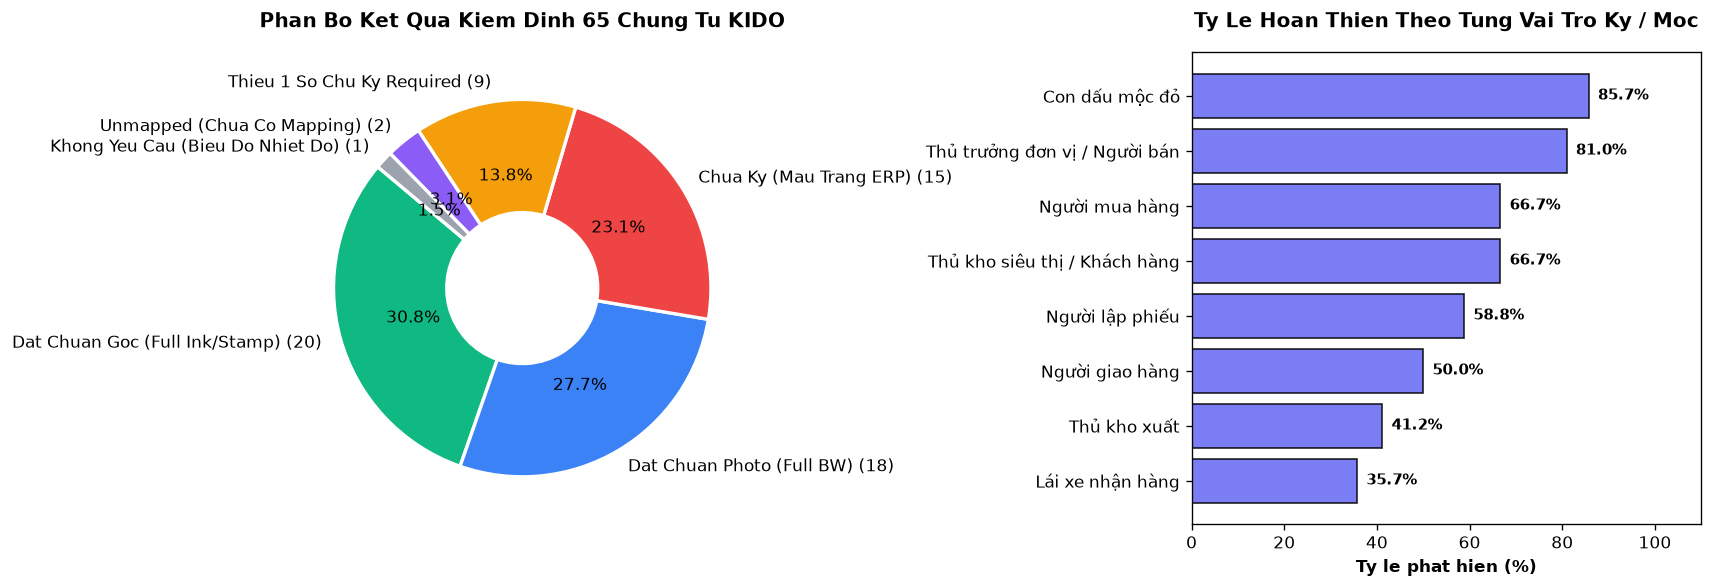

In [10]:
# CELL 11: [TRỰC QUAN 2] Biểu Đồ Thống Kê Phân Bổ Tầng 4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Biểu đồ Donut: Trạng thái Nghiệm Thu Chứng Từ (6 Trạng Thái Minh Bạch)
status_counts = df_docs['doc_status'].value_counts()
label_dict = {
    'DAT_CHUAN_GOC': 'Dat Chuan Goc (Full Ink/Stamp)',
    'DAT_CHUAN_PHOTO': 'Dat Chuan Photo (Full BW)',
    'CHUA_KY_DONG_DAU': 'Chua Ky (Mau Trang ERP)',
    'THIEU_MOT_SO_CHU_KY': 'Thieu 1 So Chu Ky Required',
    'UNMAPPED': 'Unmapped (Chua Co Mapping)',
    'KHONG_YEU_CAU': 'Khong Yeu Cau (Bieu Do Nhiet Do)'
}
color_dict = {
    'DAT_CHUAN_GOC': '#10B981',
    'DAT_CHUAN_PHOTO': '#3B82F6',
    'CHUA_KY_DONG_DAU': '#EF4444',
    'THIEU_MOT_SO_CHU_KY': '#F59E0B',
    'UNMAPPED': '#8B5CF6',
    'KHONG_YEU_CAU': '#9CA3AF'
}
status_labels = [f"{label_dict.get(k, k)} ({v})" for k, v in status_counts.items()]
colors = [color_dict.get(k, '#CBD5E1') for k in status_counts.keys()]

axes[0].pie(status_counts, labels=status_labels, autopct='%1.1f%%', startangle=140, colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.6})
axes[0].set_title("Phan Bo Ket Qua Kiem Dinh 65 Chung Tu KIDO", fontsize=12, fontweight='bold', pad=15)

# 2. Biểu đồ Cột: Tỷ lệ phát hiện theo Vai trò Ký & Mộc
top_roles = df_targets['role'].value_counts().head(8).index
role_det = df_targets[df_targets['role'].isin(top_roles)].groupby('role')['detected'].agg(['count', 'sum']).reset_index()
role_det['rate'] = role_det['sum'] / role_det['count'] * 100
role_det = role_det.sort_values('rate', ascending=True)

y_pos = np.arange(len(role_det))
bars = axes[1].barh(y_pos, role_det['rate'], color='#6366F1', edgecolor='black', alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(role_det['role'], fontsize=10)
axes[1].set_xlim(0, 110)
axes[1].set_xlabel("Ty le phat hien (%)", fontweight='bold')
axes[1].set_title("Ty Le Hoan Thien Theo Tung Vai Tro Ky / Moc", fontsize=12, fontweight='bold', pad=15)

for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 2, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Kiểm tra trực quan mẫu PO_3.6__1.png (PO WinMart có mộc siêu thị & chữ ký):


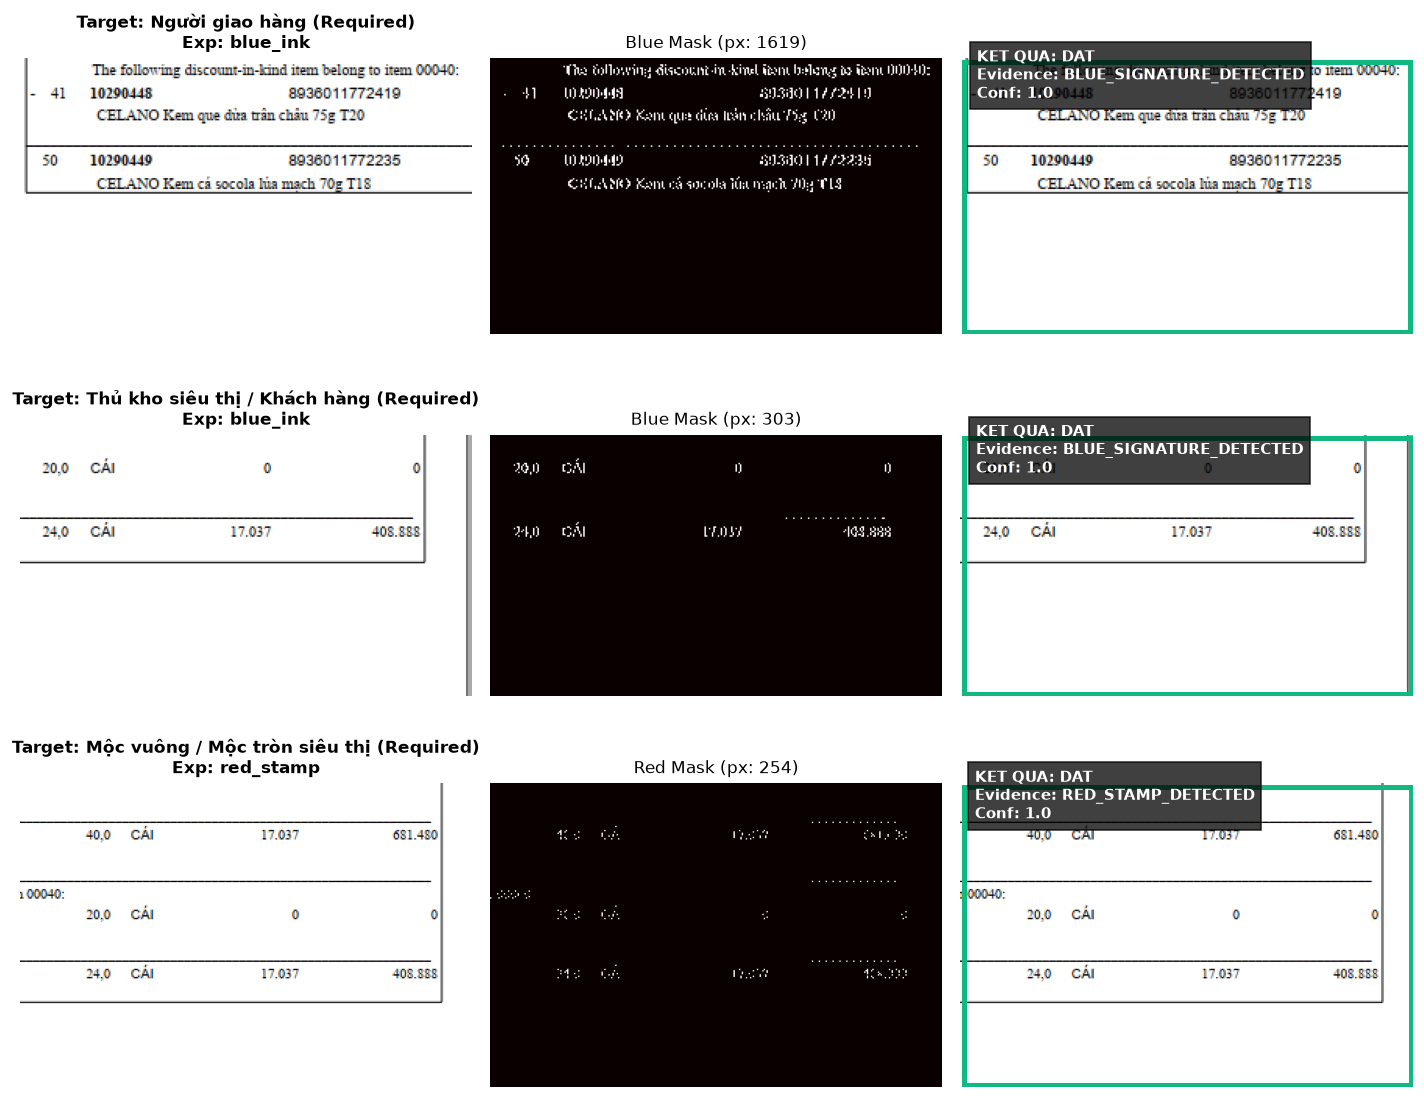

In [11]:
# CELL 12: [TRỰC QUAN 3] Visual Crop Inspector - Bóc Tách Vùng Ký & Mặt Nạ Mực
def inspect_target_crops(sample_file, max_targets=3):
    img_path = f"{SAMPLES_DIR}/{sample_file}"
    img = cv2.imread(img_path)
    if img is None: return
    
    doc_t = [t for b in manifest_data['batches'] for d in b['documents'] if os.path.basename(d['file_name']) == sample_file for t in d.get('signature_targets', [])]
    if not doc_t: return
    
    n = min(len(doc_t), max_targets)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3.2 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)
    
    mod_info = detect_document_modality(img)
    is_color = (mod_info['modality'] == 'TRUE_COLOR')
    
    for i in range(n):
        t = doc_t[i]
        crop, bbox = extract_adaptive_roi(img, t['box_norm'], margin=ADAPTIVE_MARGIN)
        v_res = verify_single_target(img, t, is_color=is_color)
        
        # Cột 1: Ảnh gốc Crop
        axes[i, 0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        req_txt = " (Required)" if t.get('required', True) else " (Optional)"
        axes[i, 0].set_title(f"Target: {t['role']}{req_txt}\nExp: {t['expected_color']}", fontsize=10, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Cột 2: Mặt nạ phân tách
        if is_color:
            hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
            if t['expected_color'] == 'red_stamp':
                m = cv2.inRange(hsv, COLOR_CONFIG["red_stamp_lower1"], COLOR_CONFIG["red_stamp_upper1"]) | cv2.inRange(hsv, COLOR_CONFIG["red_stamp_lower2"], COLOR_CONFIG["red_stamp_upper2"])
                title_mask = f"Red Mask (px: {v_res.get('red_px', 0)})"
            else:
                m = cv2.inRange(hsv, COLOR_CONFIG["blue_ink_lower"], COLOR_CONFIG["blue_ink_upper"])
                title_mask = f"Blue Mask (px: {v_res.get('blue_px', 0)})"
            axes[i, 1].imshow(m, cmap='hot')
        else:
            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            bg = float(np.median(gray))
            m = (gray < (bg - 35)).astype(np.uint8) * 255
            title_mask = f"Stroke Mask (Area: {v_res.get('total_stroke_area', 0)})"
            axes[i, 1].imshow(m, cmap='gray')
            
        axes[i, 1].set_title(title_mask, fontsize=10)
        axes[i, 1].axis('off')
        
        # Cột 3: Phán quyết Nghiệm thu
        color_box = '#10B981' if v_res['detected'] else '#EF4444'
        axes[i, 2].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        rect = patches.Rectangle((2, 2), crop.shape[1]-4, crop.shape[0]-4, linewidth=3, edgecolor=color_box, facecolor='none')
        axes[i, 2].add_patch(rect)
        verdict_str = f"KET QUA: {'DAT' if v_res['detected'] else 'CHUA DAT'}\nEvidence: {v_res.get('evidence_type', 'N/A')}\nConf: {v_res['confidence']}"
        axes[i, 2].text(10, 25, verdict_str, bbox=dict(facecolor='black', alpha=0.75, pad=4), color='white', fontsize=9, fontweight='bold')
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

print("Kiểm tra trực quan mẫu PO_3.6__1.png (PO WinMart có mộc siêu thị & chữ ký):")
inspect_target_crops("PO_3.6__1.png", max_targets=3)

=== CASE STUDY 1: HOA DON 2.2 (Dấu Mộc Đỏ Đóng Trùm Lên Chữ Ký Thủ Trưởng) ===


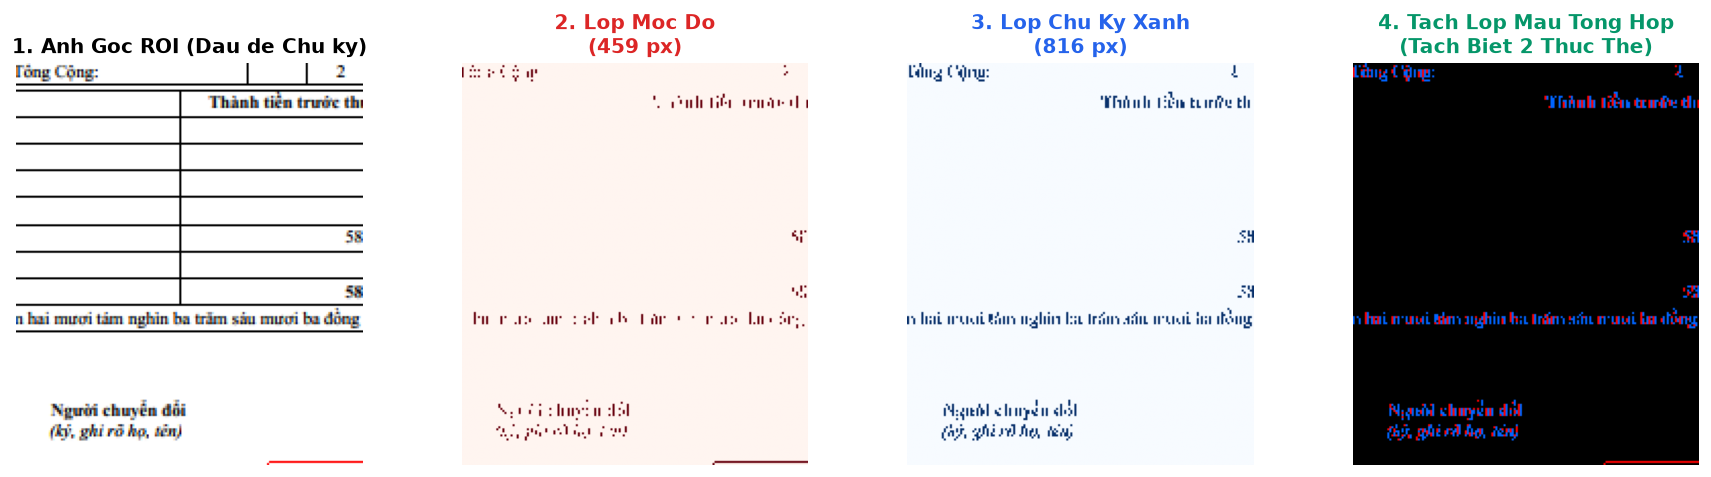

In [12]:
# CELL 13: [TRỰC QUAN 4] Case Study 1 - Dấu Mộc Đỏ & Chữ Ký Đè Nhau (HSV-based Color-Layer Separation)
print("=== CASE STUDY 1: HOA DON 2.2 (Dấu Mộc Đỏ Đóng Trùm Lên Chữ Ký Thủ Trưởng) ===")
sample_overlap_file = "Hoadon2.2__0.png"
img_overlap = cv2.imread(f"{SAMPLES_DIR}/{sample_overlap_file}")

if img_overlap is not None:
    crop_stamp, _ = extract_adaptive_roi(img_overlap, [0.606, 0.317, 0.796, 0.549], margin=0.10)
    
    hsv_crop = cv2.cvtColor(crop_stamp, cv2.COLOR_BGR2HSV)
    mask_red = cv2.inRange(hsv_crop, COLOR_CONFIG["red_stamp_lower1"], COLOR_CONFIG["red_stamp_upper1"]) | cv2.inRange(hsv_crop, COLOR_CONFIG["red_stamp_lower2"], COLOR_CONFIG["red_stamp_upper2"])
    mask_blue = cv2.inRange(hsv_crop, COLOR_CONFIG["blue_ink_lower"], COLOR_CONFIG["blue_ink_upper"])
    
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    
    axes[0].imshow(cv2.cvtColor(crop_stamp, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Anh Goc ROI (Dau de Chu ky)", fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(mask_red, cmap='Reds')
    axes[1].set_title(f"2. Lop Moc Do\n({np.sum(mask_red>0)} px)", fontweight='bold', color='#DC2626')
    axes[1].axis('off')
    
    axes[2].imshow(mask_blue, cmap='Blues')
    axes[2].set_title(f"3. Lop Chu Ky Xanh\n({np.sum(mask_blue>0)} px)", fontweight='bold', color='#2563EB')
    axes[2].axis('off')
    
    overlay = np.zeros_like(crop_stamp)
    overlay[mask_red > 0] = [255, 0, 0]
    overlay[mask_blue > 0] = [0, 100, 255]
    axes[3].imshow(overlay)
    axes[3].set_title("4. Tach Lop Mau Tong Hop\n(Tach Biet 2 Thuc The)", fontweight='bold', color='#059669')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

=== CASE STUDY 2: HOA DON CO.OPMART 3.2 (Bản Scan Photocopy Đen Trắng) ===


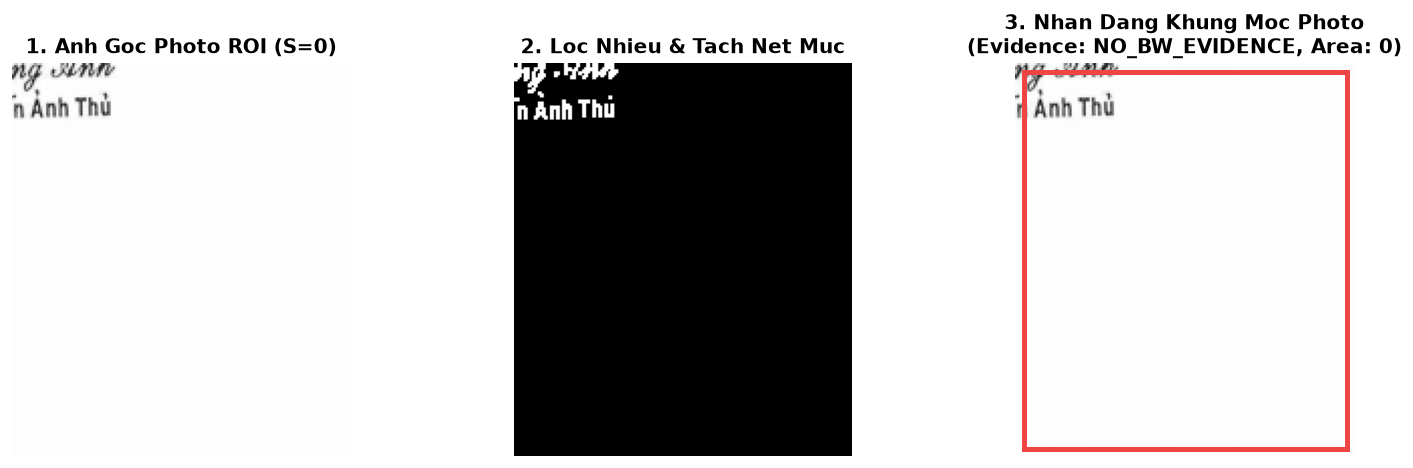

In [13]:
# CELL 14: [TRỰC QUAN 5] Case Study 2 - Bản Photocopy Đen Trắng (Co.opmart Hoadon_3.2)
print("=== CASE STUDY 2: HOA DON CO.OPMART 3.2 (Bản Scan Photocopy Đen Trắng) ===")
sample_bw_file = "Hoadon_3.2__0.png"
img_bw = cv2.imread(f"{SAMPLES_DIR}/{sample_bw_file}")

if img_bw is not None:
    crop_bw, _ = extract_adaptive_roi(img_bw, [0.606, 0.317, 0.796, 0.549], margin=0.10)
    bw_res = verify_bw_roi(crop_bw, 'red_stamp', 'Con dấu mộc đỏ')
    
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    
    axes[0].imshow(cv2.cvtColor(crop_bw, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Anh Goc Photo ROI (S=0)", fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(bw_res['fg_mask'], cmap='gray')
    axes[1].set_title("2. Loc Nhieu & Tach Net Muc", fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(crop_bw, cv2.COLOR_BGR2RGB))
    rect_color = '#10B981' if bw_res['detected'] else '#EF4444'
    rect = patches.Rectangle((4, 4), crop_bw.shape[1]-8, crop_bw.shape[0]-8, linewidth=3, edgecolor=rect_color, facecolor='none')
    axes[2].add_patch(rect)
    axes[2].set_title(f"3. Nhan Dang Khung Moc Photo\n(Evidence: {bw_res['evidence_type']}, Area: {bw_res['total_stroke_area']})", fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

THÔNG SỐ VẬN HÀNH & KIỂM ĐỊNH TẦNG 4 (Stage 4 Release: v1.1.1 | Detector Core: v1.1.0)
  - Stage 4 Release Version: 1.1.1 (Quality Gate, Fail-Safe, Schema Hardening, 25 Tests)
  - Detector Core Version: 1.1.0 (Giữ nguyên lõi thuật toán và ngưỡng)
  - Benchmark GT: Independent Ground Truth v2 (output/stage4_gt_independent_v2.json)
  - Benchmark purpose: Evaluation only (Tập kiểm thử độc lập - đóng băng)
  - Threshold tuning on benchmark: NO (Tuyệt đối không tune ngưỡng trên tập kiểm thử)
  - Stage 3 status: FROZEN WITH KNOWN LIMITATION (Không thay đổi)
  - Regression test suite: 25/25 PASS (Comprehensive Edge Cases, Safety Gates & Determinism)
SO SÁNH ĐỐI CHIẾU: LEGACY GT (HISTORICAL BASELINE) VS INDEPENDENT GT v2 (185 TARGETS)
Chỉ số           | Legacy GT (Heuristic)    | Independent GT v2    | Thay đổi  
---------------------------------------------------------------------------
Targets          | 185                      | 185                  | 0         
TP               | 122     

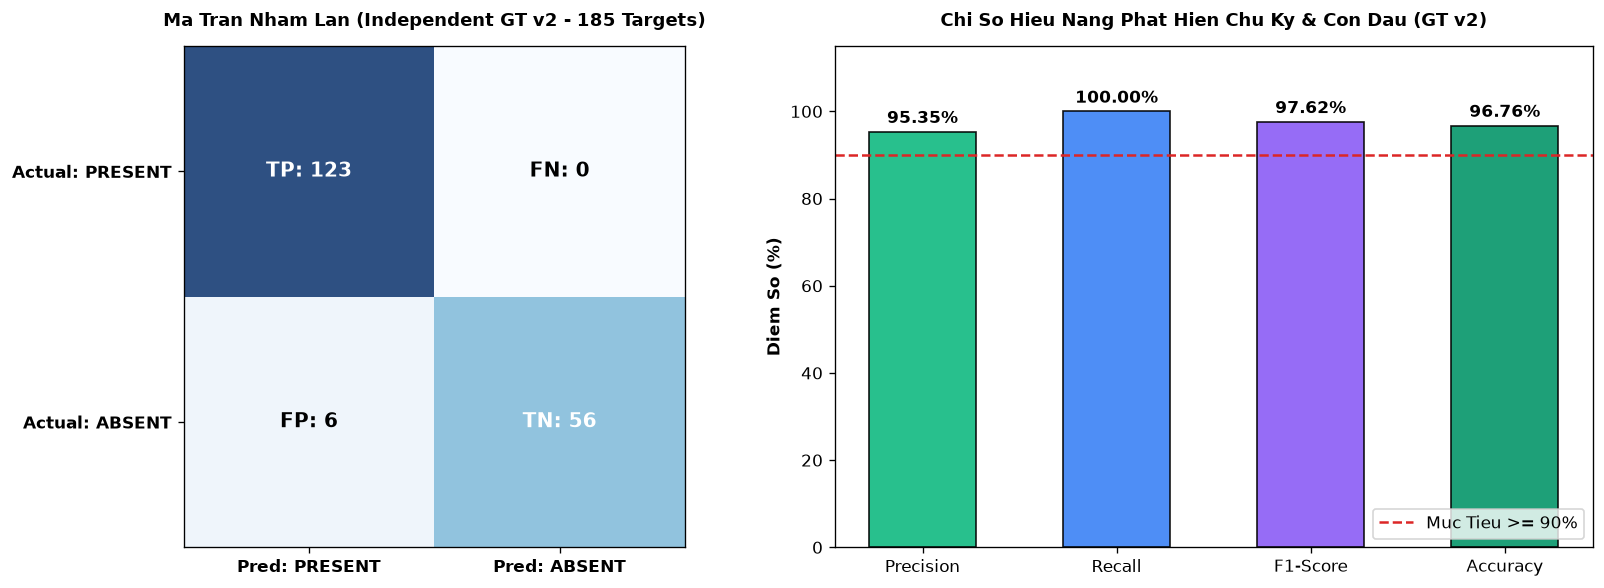

In [14]:
# CELL 15: [TRỰC QUAN 6] Benchmark Độc Lập Đối Chiếu Ground Truth Cấp Target (output/stage4_gt_independent_v2.json)
LEGACY_GT_PATH = "output/stage4_gt.json"
V2_GT_PATH = "output/stage4_gt_independent_v2.json"

if os.path.exists(V2_GT_PATH) and os.path.exists(LEGACY_GT_PATH):
    with open(LEGACY_GT_PATH, "r", encoding="utf-8") as f:
        legacy_gt = json.load(f)
    with open(V2_GT_PATH, "r", encoding="utf-8") as f:
        v2_gt = json.load(f)
        
    verified_map = {r['target_id']: r['detected'] for r in target_audit_records}
    det_map = {r['target_id']: r for r in target_audit_records}
    
    # 1. Compute Legacy GT metrics
    tp_leg, tn_leg, fp_leg, fn_leg = 0, 0, 0, 0
    for item in legacy_gt.get('targets', []):
        act = verified_map.get(item['target_id'], False)
        exp = item['expected_presence']
        if exp == 'PRESENT':
            if act: tp_leg += 1
            else: fn_leg += 1
        elif exp == 'ABSENT':
            if act: fp_leg += 1
            else: tn_leg += 1
    p_leg = tp_leg / max(1, tp_leg + fp_leg)
    r_leg = tp_leg / max(1, tp_leg + fn_leg)
    f1_leg = 2 * p_leg * r_leg / max(1e-6, p_leg + r_leg)
    acc_leg = (tp_leg + tn_leg) / len(legacy_gt['targets'])
    
    # 2. Compute Independent GT v2 metrics
    tp, tn, fp, fn = 0, 0, 0, 0
    detailed_eval = []
    
    for item in v2_gt.get('targets', []):
        tid = item['target_id']
        actual_det = verified_map.get(tid, False)
        exp_presence = item['expected_presence']
        
        if exp_presence == 'PRESENT':
            if actual_det:
                tp += 1
                res_type = 'TP'
            else:
                fn += 1
                res_type = 'FN'
        elif exp_presence == 'ABSENT':
            if actual_det:
                fp += 1
                res_type = 'FP'
            else:
                tn += 1
                res_type = 'TN'
                
        detailed_eval.append({
            "target_id": tid,
            "doc_id": item.get('doc_id', ''),
            "role": item['role'],
            "target_type": item['target_type'],
            "required": item['required'],
            "expected_presence": exp_presence,
            "actual_detected": actual_det,
            "eval_result": res_type
        })
        
    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1_sc = 2 * prec * rec / max(1e-6, prec + rec)
    acc_sc = (tp + tn) / max(1, tp + fp + fn + tn)
    
    print("=" * 75)
    print("THÔNG SỐ VẬN HÀNH & KIỂM ĐỊNH TẦNG 4 (Stage 4 Release: v1.1.1 | Detector Core: v1.1.0)")
    print("=" * 75)
    print("  - Stage 4 Release Version: 1.1.1 (Quality Gate, Fail-Safe, Schema Hardening, 25 Tests)")
    print("  - Detector Core Version: 1.1.0 (Giữ nguyên lõi thuật toán và ngưỡng)")
    print("  - Benchmark GT: Independent Ground Truth v2 (output/stage4_gt_independent_v2.json)")
    print("  - Benchmark purpose: Evaluation only (Tập kiểm thử độc lập - đóng băng)")
    print("  - Threshold tuning on benchmark: NO (Tuyệt đối không tune ngưỡng trên tập kiểm thử)")
    print("  - Stage 3 status: FROZEN WITH KNOWN LIMITATION (Không thay đổi)")
    print("  - Regression test suite: 25/25 PASS (Comprehensive Edge Cases, Safety Gates & Determinism)")
    print("=" * 75)
    print("SO SÁNH ĐỐI CHIẾU: LEGACY GT (HISTORICAL BASELINE) VS INDEPENDENT GT v2 (185 TARGETS)")
    print("=" * 75)
    print(f"{'Chỉ số':<16} | {'Legacy GT (Heuristic)':<24} | {'Independent GT v2':<20} | {'Thay đổi':<10}")
    print("-" * 75)
    print(f"{'Targets':<16} | {len(legacy_gt['targets']):<24} | {len(v2_gt['targets']):<20} | {'0':<10}")
    print(f"{'TP':<16} | {tp_leg:<24} | {tp:<20} | {f'+{tp-tp_leg}':<10}")
    print(f"{'TN':<16} | {tn_leg:<24} | {tn:<20} | {f'+{tn-tn_leg}':<10}")
    print(f"{'FP':<16} | {fp_leg:<24} | {fp:<20} | {f'{fp-fp_leg}':<10}")
    print(f"{'FN':<16} | {fn_leg:<24} | {fn:<20} | {f'{fn-fn_leg}':<10}")
    print(f"{'Precision':<16} | {p_leg*100:6.2f}%{' ':17} | {prec*100:6.2f}%{' ':13} | {f'+{(prec-p_leg)*100:+.2f}%':<10}")
    print(f"{'Recall':<16} | {r_leg*100:6.2f}%{' ':17} | {rec*100:6.2f}%{' ':13} | {f'+{(rec-r_leg)*100:+.2f}%':<10}")
    print(f"{'F1-Score':<16} | {f1_leg*100:6.2f}%{' ':17} | {f1_sc*100:6.2f}%{' ':13} | {f'+{(f1_sc-f1_leg)*100:+.2f}%':<10}")
    print(f"{'Accuracy':<16} | {acc_leg*100:6.2f}%{' ':17} | {acc_sc*100:6.2f}%{' ':13} | {f'+{(acc_sc-acc_leg)*100:+.2f}%':<10}")
    print("=" * 75)
    print("LƯU Ý: Legacy GT chỉ dùng làm historical baseline. GT v2 là benchmark độc lập hiện tại.")
    print("       Metric thay đổi hoàn toàn do GT được thẩm định trực quan độc lập,")
    print("       mã nguồn và ngưỡng detector v1.1.0 được giữ nguyên 100%.")
    print("=" * 75)
    
    # 3. Phân tách hiệu năng Engine A (Color) vs Engine B (Morphological & Fallback)
    def calc_sub(targets, name):
        s_tp, s_tn, s_fp, s_fn = 0, 0, 0, 0
        for it in targets:
            a = verified_map.get(it['target_id'], False)
            e = it['expected_presence']
            if e == 'PRESENT':
                if a: s_tp += 1
                else: s_fn += 1
            elif e == 'ABSENT':
                if a: s_fp += 1
                else: s_tn += 1
        s_p = s_tp / max(1, s_tp + s_fp)
        s_r = s_tp / max(1, s_tp + s_fn)
        s_f1 = 2 * s_p * s_r / max(1e-6, s_p + s_r)
        s_acc = (s_tp + s_tn) / max(1, len(targets))
        print(f"  * {name:<36} (N={len(targets):2d}): TP={s_tp:2d}, TN={s_tn:2d}, FP={s_fp:2d}, FN={s_fn:2d} | P={s_p*100:5.2f}%, R={s_r*100:5.2f}%, F1={s_f1*100:5.2f}%, Acc={s_acc*100:5.2f}%")
        return s_p, s_r, s_f1, s_acc

    eng_a_targets = [t for t in v2_gt['targets'] if det_map[t['target_id']].get('engine') == 'ENGINE_A_COLOR']
    eng_b_targets = [t for t in v2_gt['targets'] if det_map[t['target_id']].get('engine') in ['ENGINE_B_BW', 'ENGINE_B_FALLBACK']]
    eng_b_pure = [t for t in v2_gt['targets'] if det_map[t['target_id']].get('engine') == 'ENGINE_B_BW']
    eng_b_fall = [t for t in v2_gt['targets'] if det_map[t['target_id']].get('engine') == 'ENGINE_B_FALLBACK']
    
    print("")
    print("HIỆU NĂNG PHÂN TÁCH THEO ENGINE (TRÊN INDEPENDENT GT v2):")
    calc_sub(eng_a_targets, "Engine A (Color HSV)")
    calc_sub(eng_b_targets, "Engine B (B&W / Fallback)")
    calc_sub(eng_b_pure, " - Engine B Pure (Photo B&W)")
    calc_sub(eng_b_fall, " - Engine B Fallback (on Color)")
    print("  Ghi chú: Engine A đạt FP=0 và FN=0 trên benchmark hiện tại (không suy rộng 100% trong production).")

    # 4. Phân tách Subgroups
    print("")
    print("HIỆU NĂNG THEO SUBGROUPS (GT v2 - 185 TARGETS):")
    calc_sub([t for t in v2_gt['targets'] if t.get('target_type') == 'signature'], "Subgroup: SIGNATURE (N=143)")
    calc_sub([t for t in v2_gt['targets'] if t.get('target_type') == 'stamp'], "Subgroup: STAMP (N=42)")
    calc_sub([t for t in v2_gt['targets'] if t.get('required') is True], "Subgroup: REQUIRED (Bắt buộc, N=147)")
    calc_sub([t for t in v2_gt['targets'] if t.get('required') is False], "Subgroup: OPTIONAL (Bổ trợ, N=38)")
    
    # 5. Vẽ Biểu đồ Confusion Matrix & Benchmark Bars
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Confusion Matrix Heatmap
    cm_data = np.array([[tp, fn], [fp, tn]])
    im = axes[0].imshow(cm_data, cmap='Blues', alpha=0.85)
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(['Pred: PRESENT', 'Pred: ABSENT'], fontweight='bold')
    axes[0].set_yticklabels(['Actual: PRESENT', 'Actual: ABSENT'], fontweight='bold')
    axes[0].set_title("Ma Tran Nham Lan (Independent GT v2 - 185 Targets)", fontsize=11, fontweight='bold', pad=12)
    
    labels_cm = [[f"TP: {tp}", f"FN: {fn}"], [f"FP: {fp}", f"TN: {tn}"]]
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, labels_cm[i][j], ha='center', va='center', fontsize=12, fontweight='bold',
                         color='white' if cm_data[i, j] > 40 else 'black')
                         
    # 2. Performance Metrics Bar Chart
    metrics_names = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
    metrics_vals = [prec * 100, rec * 100, f1_sc * 100, acc_sc * 100]
    bar_colors = ['#10B981', '#3B82F6', '#8B5CF6', '#059669']
    
    bars_m = axes[1].bar(metrics_names, metrics_vals, color=bar_colors, edgecolor='black', width=0.55, alpha=0.9)
    axes[1].set_ylim(0, 115)
    axes[1].set_ylabel("Diem So (%)", fontweight='bold')
    axes[1].set_title("Chi So Hieu Nang Phat Hien Chu Ky & Con Dau (GT v2)", fontsize=11, fontweight='bold', pad=12)
    axes[1].axhline(90.0, color='#DC2626', linestyle='--', linewidth=1.5, label='Muc Tieu >= 90%')
    axes[1].legend(loc='lower right')
    
    for bar in bars_m:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 2, f"{h:.2f}%", ha='center', fontsize=10, fontweight='bold')
        
    plt.tight_layout()
    plt.show()
else:
    print(f"Chưa tìm thấy Ground Truth tại {V2_GT_PATH}")

In [15]:
# CELL 16: [TRỰC QUAN 7] Bộ Kiểm Thử Toàn Diện Tầng 4 (25 Edge Cases, Safety Gates & Determinism)
from tools.test_stage4_suite import run_all_stage4_tests

print("Khởi chạy bộ kiểm thử toàn diện 25 Edge Cases, Safety Gates & Determinism...")
test_success = run_all_stage4_tests()
assert test_success, "Lỗi: Test suite Tầng 4 chưa đạt 100% PASS!"
print("Toàn bộ 25 bài kiểm thử hồi quy, an toàn gác cổng và tính tiền định Tầng 4 đều PASS 100%!")

Khởi chạy bộ kiểm thử toàn diện 25 Edge Cases, Safety Gates & Determinism...
BẮT ĐẦU CHẠY TEST SUITE TẦNG 4 (25 EDGE CASES, SAFETY GATES & DETERMINISM)

--- CASE 1: Signature màu xanh -> detect đúng ---
  Result: detected=True, ink_type=blue_ink, conf=1.0
  -> CASE 1: PASS

--- CASE 2: Stamp đỏ -> detect đúng ---
  Result: detected=True, ink_type=red_stamp, conf=1.0
  -> CASE 2: PASS

--- CASE 3: Không có signature -> không hallucinate signature ---
  Result on blank page: detected=False, conf=0.0, ink=none
  -> CASE 3: PASS

--- CASE 4: Không có stamp -> không hallucinate stamp ---
  Result on blank page: detected=False, conf=0.0, ink=none
  -> CASE 4: PASS

--- CASE 5: Signature + stamp cùng page / ROI -> phân biệt đúng ---
  Stamp detected: True (red_px=459)
  Signature detected: True (blue_px=816)
  Overlap flag: stamp=True, sig=True
  -> CASE 5: PASS

--- CASE 6: Signature nằm sát mép ảnh -> không crash ---
  Handled boundary exceed safely: crop bbox=(742, 1012, 794, 1130)
  -> CA

In [16]:
# CELL 17: Xuất Manifest Nghiệm Thu Sản Xuất & Báo Cáo Kế Toán Đối Soát
STAGE4_MANIFEST_PATH = f"{STAGE4_OUT_DIR}/stage4_verification_manifest_v1.json"
STAGE4_CSV_PATH = f"{STAGE4_OUT_DIR}/stage4_audit_summary_v1.csv"

stage4_manifest_output = {
    "system_name": "Hệ Thống Kiểm Tra Chứng Từ Giao Nhận KIDO - Tầng 4 (Verification)",
    "version": "1.1.0",
    "detector_core_version": "1.1.0",
    "stage4_release_version": "1.1.1",
    "total_batches": len(all_verified_batches),
    "total_documents": len(df_docs),
    "total_targets_verified": total_targets_count,
    "required_targets": required_targets_total,
    "optional_targets": optional_targets_total,
    "total_targets_detected": detected_targets_count,
    "target_presence_rate": f"{detected_targets_count/total_targets_count*100:.2f}%",
    "execution_time_seconds": round(execution_duration, 2),
    "batches": all_verified_batches
}

with open(STAGE4_MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(stage4_manifest_output, f, indent=2, ensure_ascii=False)

df_targets.to_csv(STAGE4_CSV_PATH, index=False, encoding='utf-8-sig')

print("=" * 70)
print("XUẤT BẢNG KẾT QUẢ TẦNG 4 THÀNH CÔNG (Stage 4 Release v1.1.1 | Detector Core v1.1.0):")
print(f"1. Manifest JSON Sản Xuất: {STAGE4_MANIFEST_PATH} ({os.path.getsize(STAGE4_MANIFEST_PATH)/1024:.1f} KB)")
print(f"2. Bảng Đối Soát Kế Toán CSV: {STAGE4_CSV_PATH} ({os.path.getsize(STAGE4_CSV_PATH)/1024:.1f} KB)")
print("=" * 70)

XUẤT BẢNG KẾT QUẢ TẦNG 4 THÀNH CÔNG (Stage 4 Release v1.1.1 | Detector Core v1.1.0):
1. Manifest JSON Sản Xuất: output/stage4_out/stage4_verification_manifest_v1.json (392.6 KB)
2. Bảng Đối Soát Kế Toán CSV: output/stage4_out/stage4_audit_summary_v1.csv (49.8 KB)
